# 03 — Metabolic Stacked LSTM (Chapter 4 SF-07)

**Dataset:** `data/CGM Dataset/training_data.csv`  
**Horizon:** 60 min ahead (12 × 5 min) | **Window:** 12 readings

**Targets:** MAE < 15 mg/dL | RMSE < 20 mg/dL | R² > 0.92

**Outputs:** `data/metabolic_normalization_stats.json`, `models/metabolic_stacked_lstm.keras`, `models/metabolic_model_info.json`


In [1]:
from __future__ import annotations

import json
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import Model, layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
os.chdir(ROOT)

DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CGM_CSV = DATA_DIR / "CGM Dataset" / "training_data.csv"
WINDOW_SIZE = 12
HORIZON_STEPS = 12
TRAIN_FRACTION = 0.8
EPOCHS = 60
BATCH_SIZE = 64
RESAMPLE_RULE = "5min"

print("=" * 70)
print("METABOLIC STACKED LSTM — Chapter 4 SF-07")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"CGM CSV: {CGM_CSV}")
print("=" * 70)



METABOLIC STACKED LSTM — Chapter 4 SF-07
TensorFlow: 2.15.0
GPU: []
CGM CSV: d:\Vibe Coding\TwinPacemaker\data\CGM Dataset\training_data.csv


In [2]:
if not CGM_CSV.exists():
    raise FileNotFoundError(f"Upload or place CGM data at: {CGM_CSV}")

raw_df = pd.read_csv(CGM_CSV)
print(f"Loaded {raw_df.shape}")
print(raw_df.head(3))
print(raw_df.dtypes)

cols_lower = {c.lower(): c for c in raw_df.columns}
TIME_COL = next((cols_lower[k] for k in ("time", "timestamp", "datetime", "date") if k in cols_lower), None)
GLUCOSE_COL = next(
    (cols_lower[k] for k in ("cgm", "glucose", "bg", "sensor_glucose", "blood_glucose", "cbg") if k in cols_lower),
    None,
)
if GLUCOSE_COL is None:
    raise ValueError(f"No glucose column in {raw_df.columns.tolist()}")

META_COLS = [cols_lower[k] for k in ("cho", "carbs", "insulin", "risk", "lbgi", "hbgi") if k in cols_lower]
META_DIM = len(META_COLS)
print(f"Time={TIME_COL} | Glucose={GLUCOSE_COL} | Meta={META_COLS}")


Loaded (14401, 8)
                  Time      BG         CGM  CHO   insulin  LBGI      HBGI  \
0  2026-01-07 00:00:00  149.02  127.051335  0.0  0.013933   0.0  2.755276   
1  2026-01-07 00:03:00  149.02  122.346450  0.0  0.013933   0.0  2.755276   
2  2026-01-07 00:06:00  149.02  120.876957  0.0  0.013933   0.0  2.755276   

       Risk  
0  2.755276  
1  2.755276  
2  2.755276  
Time        object
BG         float64
CGM        float64
CHO        float64
insulin    float64
LBGI       float64
HBGI       float64
Risk       float64
dtype: object
Time=Time | Glucose=CGM | Meta=['CHO', 'insulin', 'Risk', 'LBGI', 'HBGI']


In [3]:
raw_df[TIME_COL] = pd.to_datetime(raw_df[TIME_COL])
raw_df = raw_df.sort_values(TIME_COL).set_index(TIME_COL)
df = raw_df.resample(RESAMPLE_RULE).mean(numeric_only=True).interpolate(method="time").ffill().bfill().reset_index()

df = df[df[GLUCOSE_COL].between(40, 400)].copy()
df[GLUCOSE_COL] = df[GLUCOSE_COL].interpolate().ffill().bfill()
for col in META_COLS:
    df[col] = df[col].fillna(0)

print(f"Rows @ {RESAMPLE_RULE}: {len(df):,}")
print(df[GLUCOSE_COL].describe())
hypo = (df[GLUCOSE_COL] < 70).mean() * 100
hyper = (df[GLUCOSE_COL] > 180).mean() * 100
print(f"Hypo {hypo:.1f}% | Hyper {hyper:.1f}% | Normal {100-hypo-hyper:.1f}%")


Rows @ 5min: 8,641
count    8641.000000
mean      118.561803
std        19.315758
min        60.926244
25%       104.312600
50%       117.802136
75%       132.102374
max       214.814265
Name: CGM, dtype: float64
Hypo 0.2% | Hyper 0.2% | Normal 99.6%


In [4]:
glucose = df[GLUCOSE_COL].values.astype(np.float32)
meta = df[META_COLS].values.astype(np.float32) if META_COLS else np.zeros((len(df), 0), np.float32)

X_ts_list, X_meta_list, y_list = [], [], []
for i in range(len(glucose) - WINDOW_SIZE - HORIZON_STEPS):
    target = glucose[i + WINDOW_SIZE + HORIZON_STEPS - 1]
    if not (40 <= target <= 400):
        continue
    X_ts_list.append(glucose[i : i + WINDOW_SIZE])
    y_list.append(target)
    if META_COLS:
        X_meta_list.append(meta[i + WINDOW_SIZE - 1])

X_ts = np.array(X_ts_list, np.float32)
y_vals = np.array(y_list, np.float32)
X_meta = np.array(X_meta_list, np.float32) if META_COLS else np.zeros((len(y_vals), 0), np.float32)
print(f"Sequences: {len(y_vals):,} | X_ts {X_ts.shape} | X_meta {X_meta.shape}")

split_idx = int(len(y_vals) * TRAIN_FRACTION)
X_ts_train, X_meta_train, y_train = X_ts[:split_idx], X_meta[:split_idx], y_vals[:split_idx]
X_ts_test, X_meta_test, y_test = X_ts[split_idx:], X_meta[split_idx:], y_vals[split_idx:]
print(f"Chronological split — train {len(y_train):,} | test {len(y_test):,}")


Sequences: 8,617 | X_ts (8617, 12) | X_meta (8617, 5)
Chronological split — train 6,893 | test 1,724


In [5]:
ts_scaler = StandardScaler()
X_ts_train_scaled = ts_scaler.fit_transform(X_ts_train.reshape(-1, 1)).reshape(len(y_train), WINDOW_SIZE, 1)
X_ts_test_scaled = ts_scaler.transform(X_ts_test.reshape(-1, 1)).reshape(len(y_test), WINDOW_SIZE, 1)

if META_DIM:
    meta_scaler = StandardScaler()
    X_meta_train_scaled = meta_scaler.fit_transform(X_meta_train)
    X_meta_test_scaled = meta_scaler.transform(X_meta_test)
else:
    meta_scaler = None
    X_meta_train_scaled, X_meta_test_scaled = X_meta_train, X_meta_test

norm_stats = {
    "scaler": "StandardScaler",
    "dataset_path": str(CGM_CSV),
    "resample_rule": RESAMPLE_RULE,
    "glucose_column": GLUCOSE_COL,
    "metadata_columns": META_COLS,
    "window_size": WINDOW_SIZE,
    "horizon_steps": HORIZON_STEPS,
    "horizon_minutes": HORIZON_STEPS * 5,
    "timeseries": {"mean": float(ts_scaler.mean_[0]), "scale": float(ts_scaler.scale_[0]), "var": float(ts_scaler.var_[0])},
    "metadata": {"mean": meta_scaler.mean_.tolist(), "scale": meta_scaler.scale_.tolist()} if META_DIM else {},
    "split": {"strategy": "chronological", "train_fraction": TRAIN_FRACTION},
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
with open(DATA_DIR / "metabolic_normalization_stats.json", "w", encoding="utf-8") as f:
    json.dump(norm_stats, f, indent=2)
print("Saved data/metabolic_normalization_stats.json")
print(f"Glucose mean={ts_scaler.mean_[0]:.2f} std={ts_scaler.scale_[0]:.2f}")


Saved data/metabolic_normalization_stats.json
Glucose mean=117.96 std=19.23


In [6]:
def build_metabolic_stacked_lstm(ts_shape, meta_dim):
    ts_input = layers.Input(shape=ts_shape, name="timeseries_input")
    x = layers.Dropout(0.3)(layers.LSTM(128, return_sequences=True, name="lstm_1")(ts_input))
    x = layers.Dropout(0.3)(layers.LSTM(64, return_sequences=True, name="lstm_2")(x))
    x = layers.Dropout(0.3)(layers.LSTM(32, return_sequences=False, name="lstm_3")(x))
    lstm_out = layers.Dense(16, activation="relu", name="lstm_dense")(x)
    if meta_dim > 0:
        meta_input = layers.Input(shape=(meta_dim,), name="metadata_input")
        m = layers.Dropout(0.2)(layers.Dense(8, activation="relu", name="meta_dense_2")(
            layers.Dense(16, activation="relu", name="meta_dense_1")(meta_input)
        ))
        fusion = layers.Concatenate(name="fusion")([lstm_out, m])
        inputs = [ts_input, meta_input]
    else:
        fusion = lstm_out
        inputs = ts_input
    fusion = layers.Dropout(0.2)(layers.Dense(8, activation="relu", name="fusion_dense_2")(
        layers.Dense(16, activation="relu", name="fusion_dense_1")(fusion)
    ))
    output = layers.Dense(1, activation="linear", name="future_glucose_target")(fusion)
    model = Model(inputs=inputs, outputs=output, name="Stacked_LSTM_Metabolic")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

model = build_metabolic_stacked_lstm((WINDOW_SIZE, 1), META_DIM)
model.summary()



Model: "Stacked_LSTM_Metabolic"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 timeseries_input (InputLay  [(None, 12, 1)]              0         []                            
 er)                                                                                              
                                                                                                  
 lstm_1 (LSTM)               (None, 12, 128)              66560     ['timeseries_input[0][0]']    
                                                                                                  
 dropout (Dropout)           (None, 12, 128)              0         ['lstm_1[0][0]']              
                                                                                                  
 lstm_2 (LSTM)               (None, 12, 64)               49408     ['dropou

In [7]:
train_X = [X_ts_train_scaled, X_meta_train_scaled] if META_DIM else X_ts_train_scaled
test_X = [X_ts_test_scaled, X_meta_test_scaled] if META_DIM else X_ts_test_scaled

history = model.fit(
    train_X, y_train,
    validation_data=(test_X, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping("val_mae", patience=15, restore_best_weights=True, mode="min"),
        keras.callbacks.ReduceLROnPlateau("val_mae", factor=0.5, patience=7, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint(str(MODELS_DIR / "metabolic_stacked_lstm_best.keras"), "val_mae", save_best_only=True, mode="min"),
    ],
    verbose=1,
)


Epoch 1/60


108/108 [==============================] - 21s 73ms/step - loss: 11232.8018 - mae: 103.0284 - val_loss: 4752.1230 - val_mae: 66.5863 - lr: 0.0010
Epoch 2/60
108/108 [==============================] - 5s 42ms/step - loss: 1941.4949 - mae: 35.2589 - val_loss: 476.8143 - val_mae: 17.7307 - lr: 0.0010
Epoch 3/60
108/108 [==============================] - 5s 44ms/step - loss: 1521.8258 - mae: 31.0050 - val_loss: 467.4740 - val_mae: 17.4541 - lr: 0.0010
Epoch 4/60
108/108 [==============================] - 5s 44ms/step - loss: 1474.4812 - mae: 30.5213 - val_loss: 410.5923 - val_mae: 16.1866 - lr: 0.0010
Epoch 5/60
108/108 [==============================] - 5s 47ms/step - loss: 1500.9393 - mae: 30.7600 - val_loss: 425.0899 - val_mae: 16.4821 - lr: 0.0010
Epoch 6/60
108/108 [==============================] - 7s 64ms/step - loss: 1442.1699 - mae: 29.9069 - val_loss: 396.8347 - val_mae: 15.8298 - lr: 0.0010
Epoch 7/60
108/108 [==============================] - 7s 61ms/step - loss: 1

MAE 15.13 | RMSE 19.05 | R² 0.0233
Within ±15: 55.4% | RMSE 0.190 g/L
[WARN] CHECK METRICS


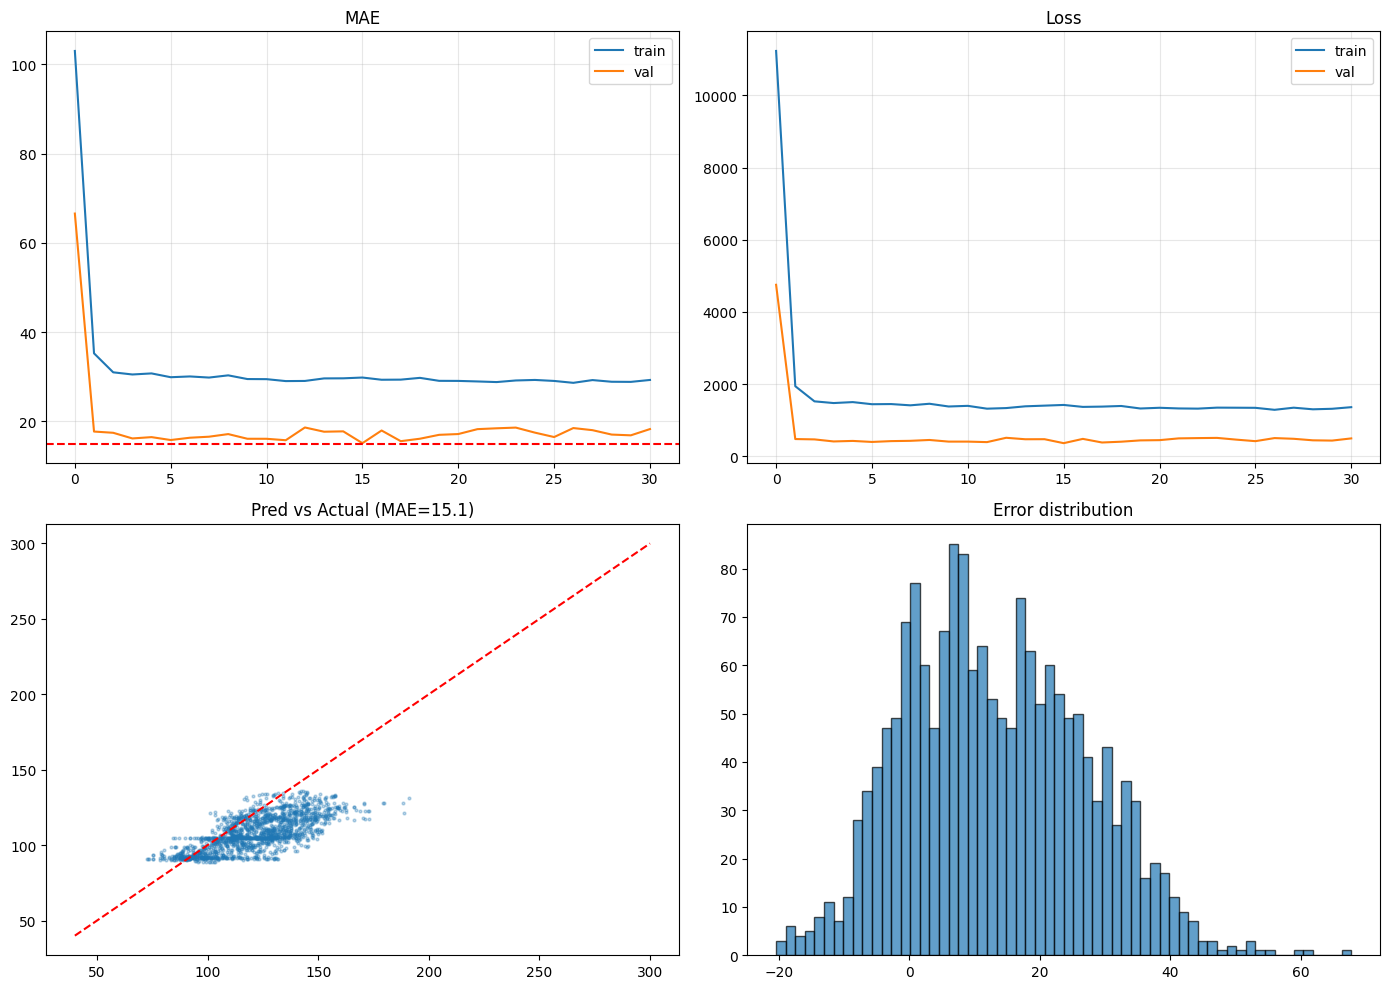

Saved models/metabolic_stacked_lstm.keras
Saved models/metabolic_model_info.json


In [8]:
y_pred = model.predict(test_X, verbose=0).flatten()
mae = float(mean_absolute_error(y_test, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = float(r2_score(y_test, y_pred))
within_15 = float(np.mean(np.abs(y_test - y_pred) <= 15) * 100)
within_20 = float(np.mean(np.abs(y_test - y_pred) <= 20) * 100)
rmse_gl = rmse / 100
target_met = mae < 15 and rmse < 20 and r2 > 0.92

print("=" * 70)
print(f"MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.4f}")
print(f"Within ±15: {within_15:.1f}% | RMSE {rmse_gl:.3f} g/L")
print("[OK] ALL TARGETS MET" if target_met else "[WARN] CHECK METRICS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(history.history["mae"], label="train")
axes[0, 0].plot(history.history["val_mae"], label="val")
axes[0, 0].axhline(15, color="r", ls="--")
axes[0, 0].set_title("MAE"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].plot(history.history["loss"], label="train")
axes[0, 1].plot(history.history["val_loss"], label="val")
axes[0, 1].set_title("Loss"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[1, 0].scatter(y_test, y_pred, s=4, alpha=0.3)
axes[1, 0].plot([40, 300], [40, 300], "r--")
axes[1, 0].set_title(f"Pred vs Actual (MAE={mae:.1f})")
axes[1, 1].hist(y_test - y_pred, bins=60, edgecolor="black", alpha=0.7)
axes[1, 1].set_title("Error distribution")
plt.tight_layout()
plt.savefig(MODELS_DIR / "metabolic_training_results.png", dpi=150)
plt.show()

model.save(MODELS_DIR / "metabolic_stacked_lstm.keras")
model_info = {
    "model_name": "Metabolic Stacked LSTM",
    "artifact": "metabolic_stacked_lstm.keras",
    "chapter_reference": "Chapter 4 SF-07, Chapter 5 Section 1.4.2",
    "architecture_note": "Stacked LSTM equivalent to GRU; LSTM retenu — RMSE cible 0.12 g/L",
    "architecture": {"timeseries_shape": [WINDOW_SIZE, 1], "meta_dim": META_DIM, "lstm_units": [128, 64, 32]},
    "dataset": {"path": str(CGM_CSV), "glucose_column": GLUCOSE_COL, "metadata_columns": META_COLS},
    "normalization": norm_stats,
    "metrics": {
        "mae_mgdl": mae, "rmse_mgdl": rmse, "r2_score": r2,
        "within_15_percent": within_15, "within_20_percent": within_20,
        "rmse_gl": rmse_gl, "target_met": bool(target_met),
    },
    "training_info": {
        "epochs_trained": len(history.history["loss"]),
        "best_epoch": int(np.argmin(history.history["val_mae"])) + 1,
        "n_train": int(len(y_train)), "n_test": int(len(y_test)),
    },
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
with open(MODELS_DIR / "metabolic_model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)
print("Saved models/metabolic_stacked_lstm.keras")
print("Saved models/metabolic_model_info.json")
